<a href="https://colab.research.google.com/github/20KaRaKuM20/NM/blob/main/%D0%BB%D1%808_%D0%92%D0%B8%D1%81%D0%BE%D1%86%D1%8C%D0%BA%D0%B8%D0%B9_%D0%92%D0%BE%D0%BB%D0%BE%D0%B4%D0%B8%D0%BC%D0%B8%D1%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Варіант 3

image.png

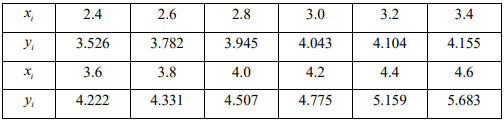

In [ ]:
import numpy as np

# Таблиця значень функції
x_values = np.array([2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4, 4.2, 4.4, 4.6])
y_values = np.array([3.526, 3.782, 3.945, 4.043, 4.104, 4.155, 4.222, 4.331, 4.507, 4.775, 5.159, 5.683])

# Крок таблиці
h = round(x_values[1] - x_values[0], 2)

# Обчислення кінцевих різниць
def finite_differences(y):
    n = len(y)
    delta_y = np.zeros((n, n))
    delta_y[:, 0] = y
    for j in range(1, n):
        for i in range(n - j):
            delta_y[i, j] = delta_y[i + 1, j - 1] - delta_y[i, j - 1]
    return delta_y

# Отримуємо таблицю кінцевих різниць
delta_table = finite_differences(y_values)

# Виводимо таблицю кінцевих різниць
print("Таблиця кінцевих різниць:")
np.set_printoptions(precision=4, suppress=True, linewidth=150)
print(delta_table)

# індекс для вузлової точки 2.6
target_x = 2.6
idx = np.where(np.isclose(x_values, target_x))[0][0]

# Беремо значення різниць саме для цього рядка
dy = delta_table[idx, 1]
d2y = delta_table[idx, 2]
d3y = delta_table[idx, 3]
d4y = delta_table[idx, 4]

# Функція для обчислення першої похідної за формулою Ньютона
def first_derivative(dy, d2y, d3y, d4y, h):
    return (1 / h * (dy - d2y / 2 + d3y / 3 - d4y / 4))

# Функція для обчислення другої похідної за формулою Ньютона
def second_derivative(d2y, d3y, d4y, h):
    return (d2y - d3y + 11 * d4y / 12) / h**2

# Обчислюємо похідні
y_prime = first_derivative(dy, d2y, d3y, d4y, h)
y_double_prime = second_derivative(d2y, d3y, d4y, h)

print(f"\nРезультати для точки x = {target_x}:")
print(f"Перша похідна y'({target_x}) ≈ {round(y_prime, 3)}")
print(f"Друга похідна y''({target_x}) ≈ {round(y_double_prime, 3)}")

Таблиця кінцевих різниць:
[[ 3.526  0.256 -0.093  0.028 -0.    -0.001  0.001  0.    -0.003  0.01  -0.025  0.056]
 [ 3.782  0.163 -0.065  0.028 -0.001 -0.     0.001 -0.003  0.007 -0.015  0.031  0.   ]
 [ 3.945  0.098 -0.037  0.027 -0.001  0.001 -0.002  0.004 -0.008  0.016  0.     0.   ]
 [ 4.043  0.061 -0.01   0.026  0.    -0.001  0.002 -0.004  0.008  0.     0.     0.   ]
 [ 4.104  0.051  0.016  0.026 -0.001  0.001 -0.002  0.004  0.     0.     0.     0.   ]
 [ 4.155  0.067  0.042  0.025  0.    -0.001  0.002  0.     0.     0.     0.     0.   ]
 [ 4.222  0.109  0.067  0.025 -0.001  0.001  0.     0.     0.     0.     0.     0.   ]
 [ 4.331  0.176  0.092  0.024  0.     0.     0.     0.     0.     0.     0.     0.   ]
 [ 4.507  0.268  0.116  0.024  0.     0.     0.     0.     0.     0.     0.     0.   ]
 [ 4.775  0.384  0.14   0.     0.     0.     0.     0.     0.     0.     0.     0.   ]
 [ 5.159  0.524  0.     0.     0.     0.     0.     0.     0.     0.     0.     0.   ]
 [ 5.683  0.     

2 спосіб

In [ ]:
import numpy as np

# Дані
x_values = np.array([2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4, 4.2, 4.4, 4.6])
y_values = np.array([3.526, 3.782, 3.945, 4.043, 4.104, 4.155, 4.222, 4.331, 4.507, 4.775, 5.159, 5.683])

# Крок таблиці
h = round(x_values[1] - x_values[0], 2)

# Обчислення масиву перших похідних
first_deriv_array = (y_values[1:] - y_values[:-1]) / h

# Обчислення масиву других похідних
second_deriv_array = (first_deriv_array[1:] - first_deriv_array[:-1]) / h

# Перша похідна (центральна різниця для вищої точності в точці 2.6)
# Формула: (y2 - y0) / (2*h)
y_prime_26 = (y_values[2] - y_values[0]) / (2 * h)

# Друга похідна в точці 2.6
y_double_prime_26 = second_deriv_array[0]

print(f"Перша похідна y'(2.6) ≈ {round(y_prime_26, 3)}")
print(f"Друга похідна y''(2.6) ≈ {round(y_double_prime_26, 3)}")

Перша похідна y'(2.6) ≈ 1.048
Друга похідна y''(2.6) ≈ -2.325


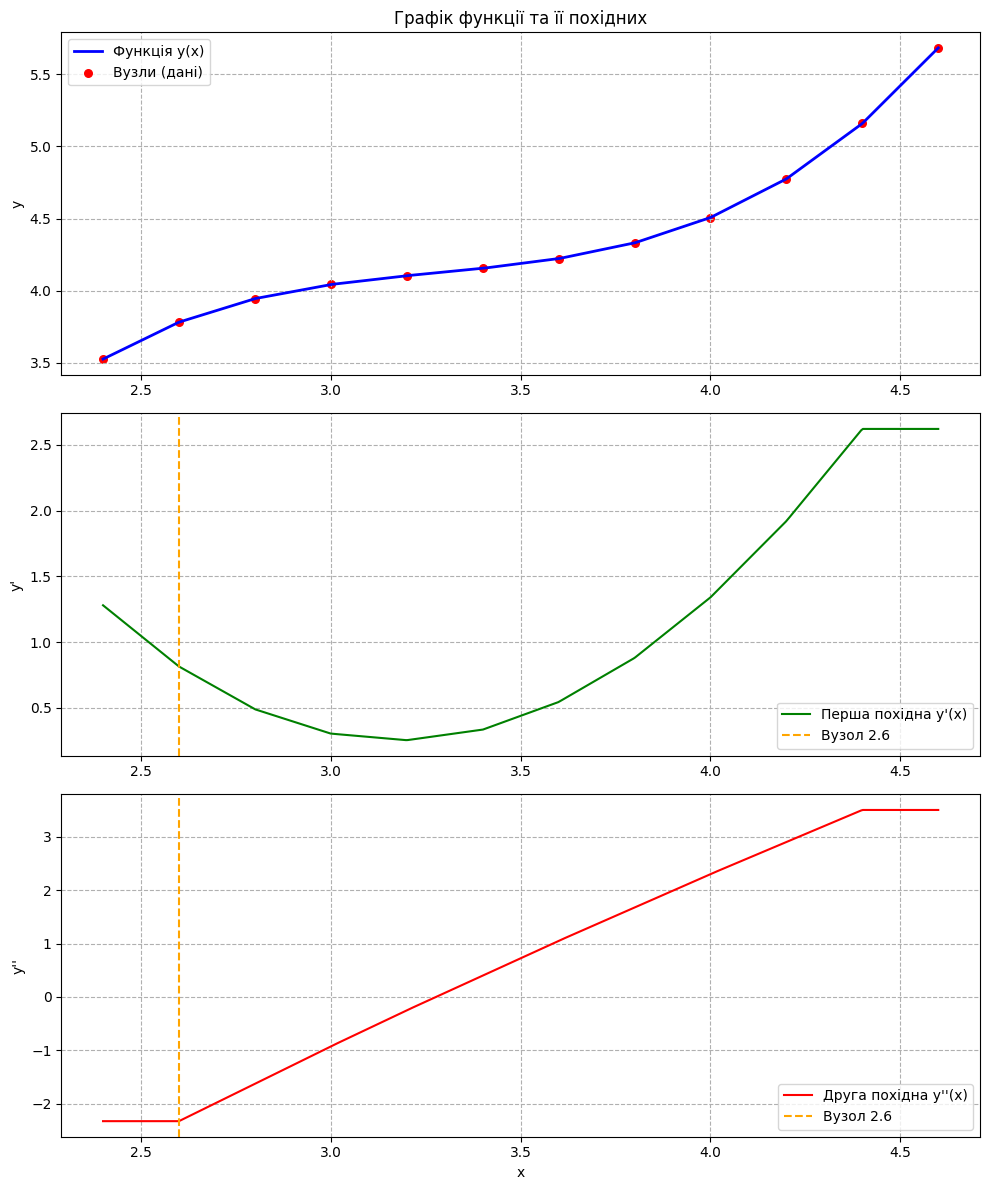

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Дані
x_values = np.array([2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8, 4, 4.2, 4.4, 4.6])
y_values = np.array([3.526, 3.782, 3.945, 4.043, 4.104, 4.155, 4.222, 4.331, 4.507, 4.775, 5.159, 5.683])

# Обчислення
h = round(x_values[1] - x_values[0], 2)

# Чисельні похідні (скінченні різниці)
first_derivative = (y_values[1:] - y_values[:-1]) / h
second_derivative = (first_derivative[1:] - first_derivative[:-1]) / h

# Підготовка даних для графіків (інтерполяція для плавності)
x_fine = np.linspace(x_values[0], x_values[-1], 500)
y_fine = np.interp(x_fine, x_values, y_values)

# Інтерполяція похідних (враховуємо зменшення довжини масивів)
# Для першої похідної використовуємо центри інтервалів x
x_first = x_values[:-1]
first_deriv_fine = np.interp(x_fine, x_first, first_derivative)

# Для другої похідної використовуємо вузли, де вона визначена
x_second = x_values[1:-1]
second_deriv_fine = np.interp(x_fine, x_second, second_derivative)

# Побудова графіків
plt.figure(figsize=(10, 12))

# Графік функції
plt.subplot(3, 1, 1)
plt.plot(x_fine, y_fine, label='Функція y(x)', color='blue', linewidth=2)
plt.scatter(x_values, y_values, color='red', s=30, label='Вузли (дані)')
plt.title('Графік функції та її похідних')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--')

# Графік першої похідної
plt.subplot(3, 1, 2)
plt.plot(x_fine, first_deriv_fine, label="Перша похідна y'(x)", color='green')
plt.axvline(x=2.6, color='orange', linestyle='--', label='Вузол 2.6')
plt.ylabel("y'")
plt.legend()
plt.grid(True, linestyle='--')

# Графік другої похідної
plt.subplot(3, 1, 3)
plt.plot(x_fine, second_deriv_fine, label="Друга похідна y''(x)", color='red')
plt.axvline(x=2.6, color='orange', linestyle='--', label='Вузол 2.6')
plt.xlabel('x')
plt.ylabel("y''")
plt.legend()
plt.grid(True, linestyle='--')

plt.tight_layout()
plt.show()